In [86]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GridSearchCV, StratifiedGroupKFold, cross_val_score
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import optuna

In [87]:
data = pd.read_csv('PD_complete(in).csv', delimiter=';')


In [89]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14'],
      dtype='object')


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature1   376 non-null    int64  
 1   Feature2   376 non-null    int64  
 2   Feature3   376 non-null    int64  
 3   Feature4   376 non-null    int64  
 4   Feature5   376 non-null    int64  
 5   Feature6   376 non-null    int64  
 6   Feature7   376 non-null    int64  
 7   Feature8   376 non-null    int64  
 8   Feature9   376 non-null    float64
 9   Feature10  376 non-null    object 
 10  Feature11  376 non-null    object 
 11  Feature12  376 non-null    object 
 12  Feature13  376 non-null    object 
 13  Feature14  376 non-null    object 
dtypes: float64(1), int64(8), object(5)
memory usage: 41.3+ KB


In [91]:
#data

In [92]:
target_column = 'Feature13'

In [93]:
data.isnull().sum()

Feature1     0
Feature2     0
Feature3     0
Feature4     0
Feature5     0
Feature6     0
Feature7     0
Feature8     0
Feature9     0
Feature10    0
Feature11    0
Feature12    0
Feature13    0
Feature14    0
dtype: int64

#### Drop rows when target column is Missing connection types

In [ ]:
data = data[data['Feature13'] != 'Missing connection types']  
data = data[data['Feature11']!='Übergangsmuffe XLPE auf Papier-Masse'] 

In [70]:
data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

In [71]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns
# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

In [72]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [73]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

           Feature2  Feature5  Feature6  Feature7  Feature8  Feature9  \
Feature2   1.000000 -0.029558  0.956203  0.193469 -0.145168 -0.230187   
Feature5  -0.029558  1.000000 -0.040713 -0.031883 -0.038485  0.050225   
Feature6   0.956203 -0.040713  1.000000  0.212611 -0.287546 -0.228531   
Feature7   0.193469 -0.031883  0.212611  1.000000  0.135080 -0.162202   
Feature8  -0.145168 -0.038485 -0.287546  0.135080  1.000000 -0.104390   
Feature9  -0.230187  0.050225 -0.228531 -0.162202 -0.104390  1.000000   
Feature10 -0.461651  0.091829 -0.567147 -0.006042  0.337474 -0.033049   
Feature11  0.132608 -0.005508  0.122308 -0.066390 -0.008454  0.168863   
Feature12  0.209863 -0.019229  0.221162 -0.128063 -0.047125  0.145216   
Feature13  0.003562 -0.060055 -0.011970 -0.119509  0.101877  0.196952   
Feature14  0.186072 -0.025595  0.277676  0.231345 -0.243605 -0.138574   

           Feature10  Feature11  Feature12  Feature13  Feature14  
Feature2   -0.461651   0.132608   0.209863   0.003562   

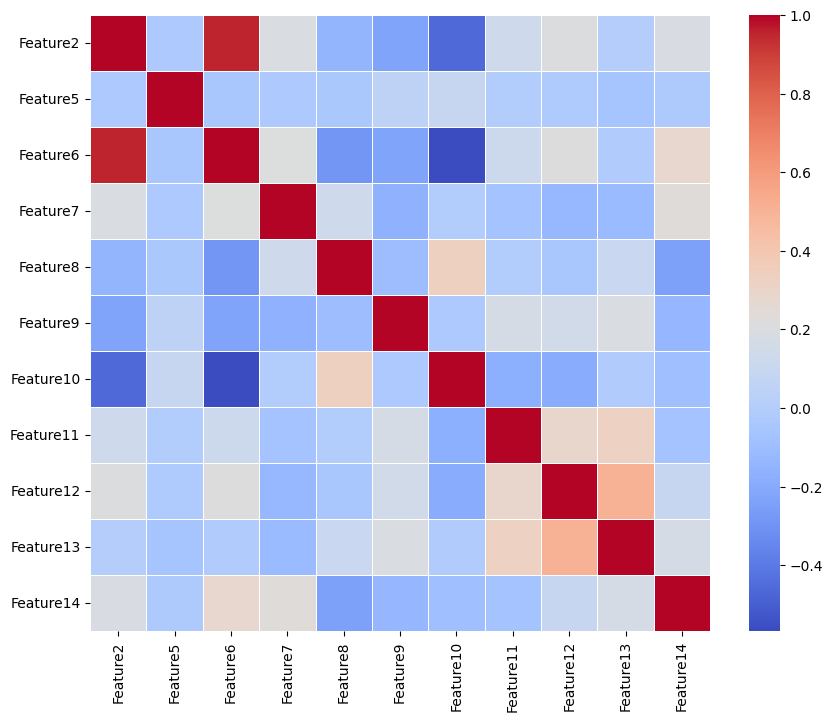

In [ ]:
#dropping id columns
data_for_analysis = data.drop(['Feature1', 'Feature3', 'Feature4'], axis=1) 
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [94]:
#data_for_analysis

In [ ]:
data_for_analysis = data_for_analysis[(data_for_analysis['Feature9'] != 43000) & (data_for_analysis['Feature9'] != 46000)] 
data_for_analysis = data_for_analysis[data_for_analysis['Feature8'] != 5063]  

In [77]:
# Column to group by but not use for training
group_column = 'Feature2'
groups = data_for_analysis['Feature2']

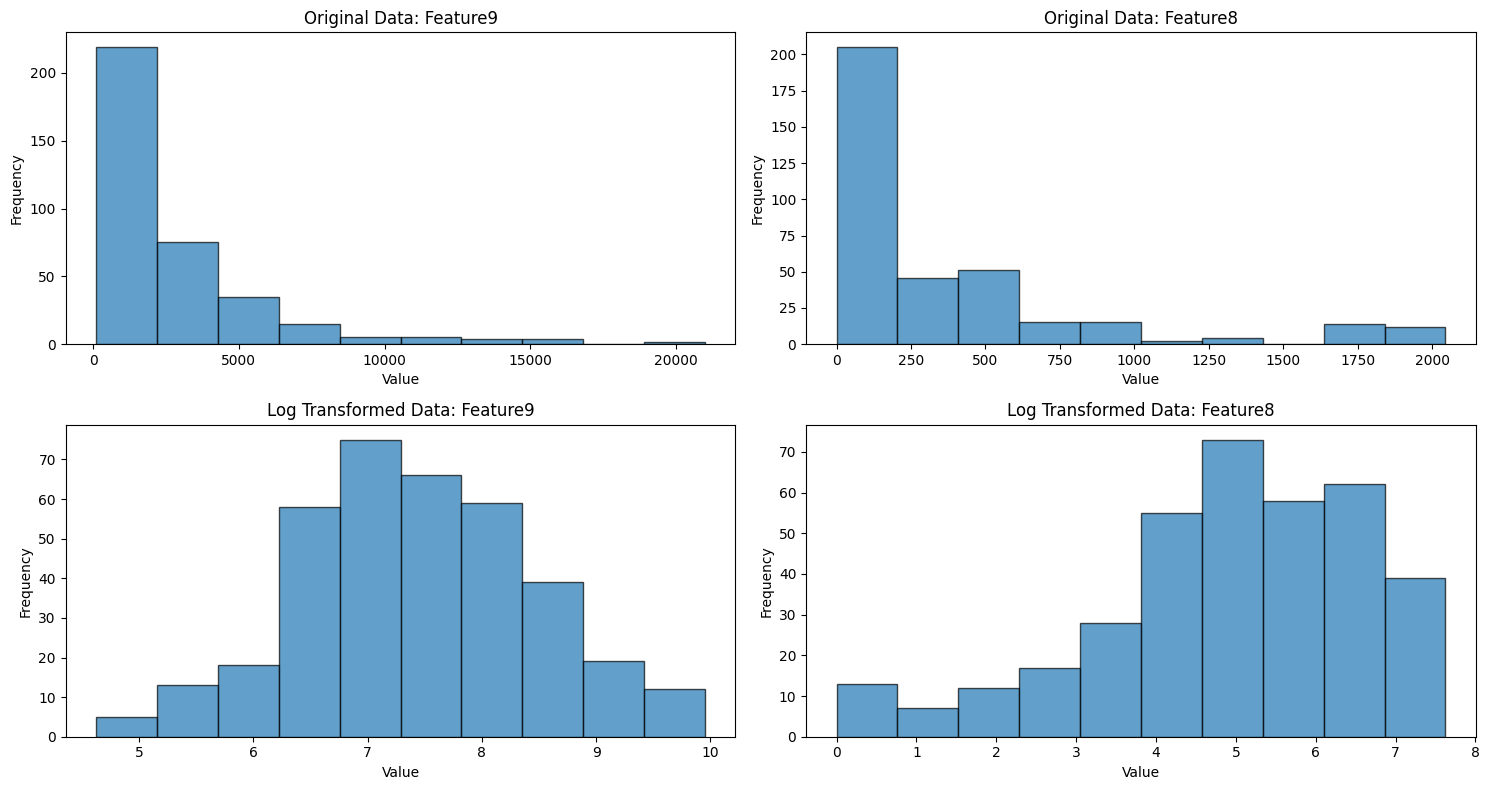

In [ ]:
# Manually specify the numerical features
numerical_features = ['Feature9', 'Feature8']  # List of numerical columns to include    
selected_data = data_for_analysis[numerical_features]

# Apply log transformation (add 1 to avoid log(0) issues)
log_transformed = selected_data.apply(lambda x: np.log1p(x))

# Plotting
fig, axes = plt.subplots(2, len(selected_data.columns), figsize=(15, 8))

# Titles for each transformation
titles = ["Original Data", "Log Transformed Data"]

# Loop through features and transformations
for i, col in enumerate(selected_data.columns):
    # Original Data
    axes[0, i].hist(selected_data[col], bins=10, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f"{titles[0]}: {col}")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")
    
    # Log Transformed Data
    axes[1, i].hist(log_transformed[col], bins=10, edgecolor='k', alpha=0.7)
    axes[1, i].set_title(f"{titles[1]}: {col}")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Frequency")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [79]:
data_for_analysis[numerical_features] = log_transformed

In [80]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column, group_column],axis=1)

In [81]:
# Standard deviation before scaling
x.std()

Feature5     0.814994
Feature6     3.013265
Feature7     1.484119
Feature8     1.693108
Feature9     1.004874
Feature10    1.059984
Feature11    0.990323
Feature12    1.541608
Feature14    0.660661
dtype: float64

In [82]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [83]:
# standard deviation after scaling
x_standardized.std()

Feature5     1.001376
Feature6     1.001376
Feature7     1.001376
Feature8     1.001376
Feature9     1.001376
Feature10    1.001376
Feature11    1.001376
Feature12    1.001376
Feature14    1.001376
dtype: float64

In [84]:
x_standardized.columns

Index(['Feature5', 'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature14'],
      dtype='object')

In [85]:
# Initialize GroupShuffleSplit
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Split the data
train_idx, test_idx = next(gss.split(x_standardized, y, groups=groups))

# Create train and test sets
X_train, X_test = x_standardized.iloc[train_idx], x_standardized.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


### Encode step voltage
log transformation first and then do the std deviation

### Supervised Modelling

#### XGBoost

In [26]:
def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.8904
F1 Score: 0.8622


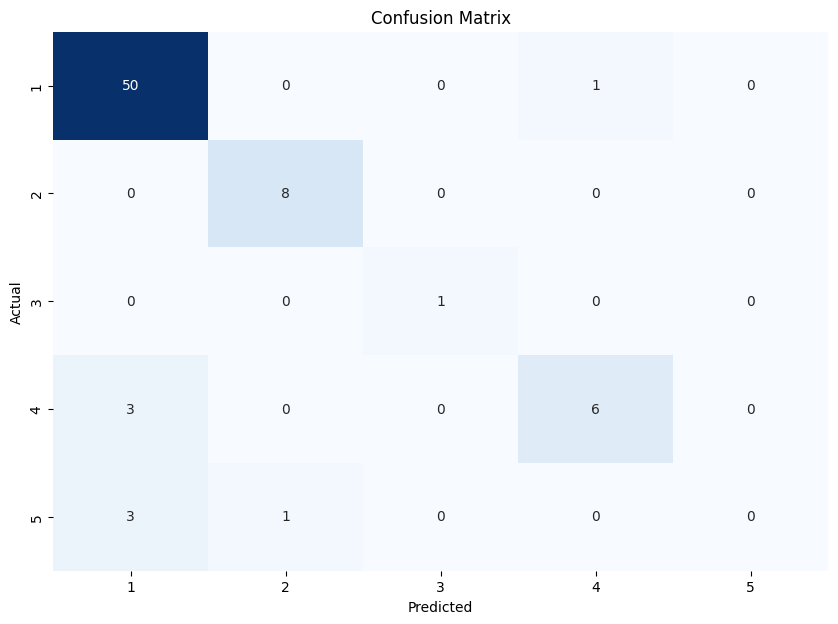

<Figure size 1000x600 with 0 Axes>

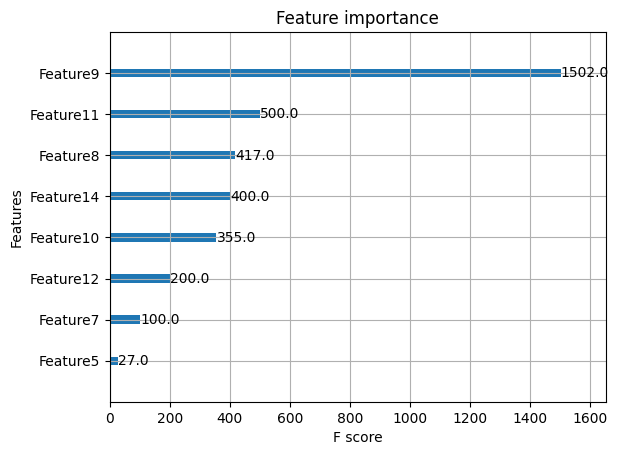

In [27]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


In [28]:

def objective_xgb(trial, X_train, y_train, cv=3):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)
    max_depth = trial.suggest_int('max_depth', 3, 6, step=1)
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    subsample = trial.suggest_float('subsample', 0.8, 1.0, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    gamma = trial.suggest_float('gamma', 0, 5, step=1)

    # Initialize model
    xgb = XGBClassifier(
        objective='multi:softmax',
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        random_state=20,
        eval_metric='mlogloss',
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1

In [30]:
def xgboost_classifier_with_optuna(X, y, n_trials=30, cv=3):
    """Runs Optuna to optimize hyperparameters and train the best XGBoost model."""
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_xgb(trial, X_train, y_train, cv=cv), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = XGBClassifier(**best_params, objective='multi:softmax', random_state=20, eval_metric='mlogloss', n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=np.unique(y_test), 
                yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-05-07 17:05:53,287] A new study created in memory with name: no-name-55a33c00-1514-4e72-93b8-1c6bf49d5363
[I 2025-05-07 17:05:55,479] Trial 0 finished with value: 0.910694019262349 and parameters: {'learning_rate': 0.08, 'max_depth': 6, 'n_estimators': 180, 'subsample': 0.9, 'colsample_bytree': 0.6, 'gamma': 1.0}. Best is trial 0 with value: 0.910694019262349.
[I 2025-05-07 17:05:57,032] Trial 1 finished with value: 0.8698883920688125 and parameters: {'learning_rate': 0.15000000000000002, 'max_depth': 5, 'n_estimators': 140, 'subsample': 0.9, 'colsample_bytree': 1.0, 'gamma': 4.0}. Best is trial 0 with value: 0.910694019262349.
[I 2025-05-07 17:05:58,530] Trial 2 finished with value: 0.8837704210223222 and parameters: {'learning_rate': 0.18000000000000002, 'max_depth': 5, 'n_estimators': 120, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 2.0}. Best is trial 0 with value: 0.910694019262349.
[I 2025-05-07 17:05:58,618] Trial 3 finished with value: 0.8448378330053136 and par

Best Parameters: {'learning_rate': 0.15000000000000002, 'max_depth': 3, 'n_estimators': 80, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 0.0}
Test Accuracy: 0.9726
Test F1 Score: 0.9595


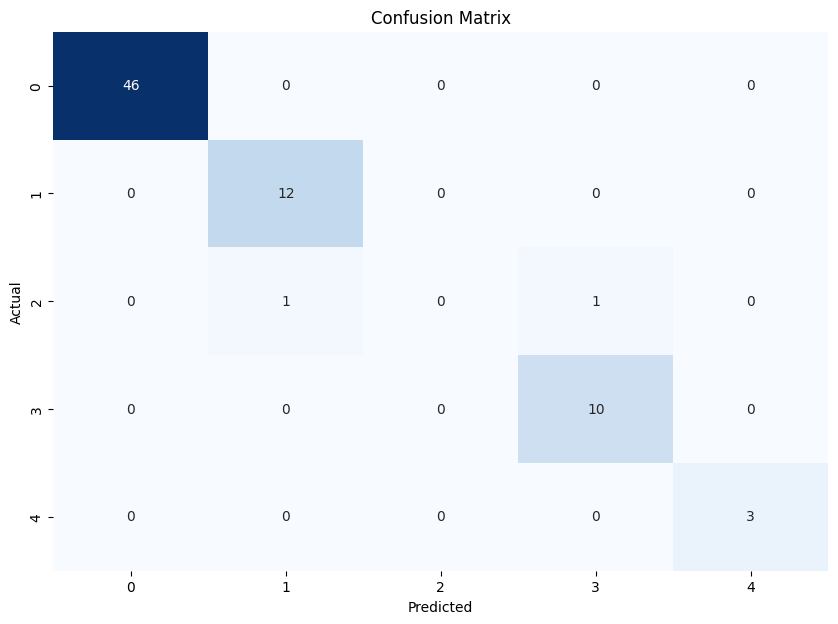

Optimal Parameters: {'learning_rate': 0.15000000000000002, 'max_depth': 3, 'n_estimators': 80, 'subsample': 1.0, 'colsample_bytree': 0.9, 'gamma': 0.0}
Test Accuracy: 0.9726027397260274
F1 Score: 0.9595042400521852


In [31]:
best_model_xgb, best_params, accuracy, f1, cm = xgboost_classifier_with_optuna(x_standardized, y_adjusted, n_trials=30, cv=3)

# Results
print(f"Optimal Parameters: {best_params}")
print(f"Test Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


#### Random Forest

In [32]:
def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9315
F1 Score: 0.9230


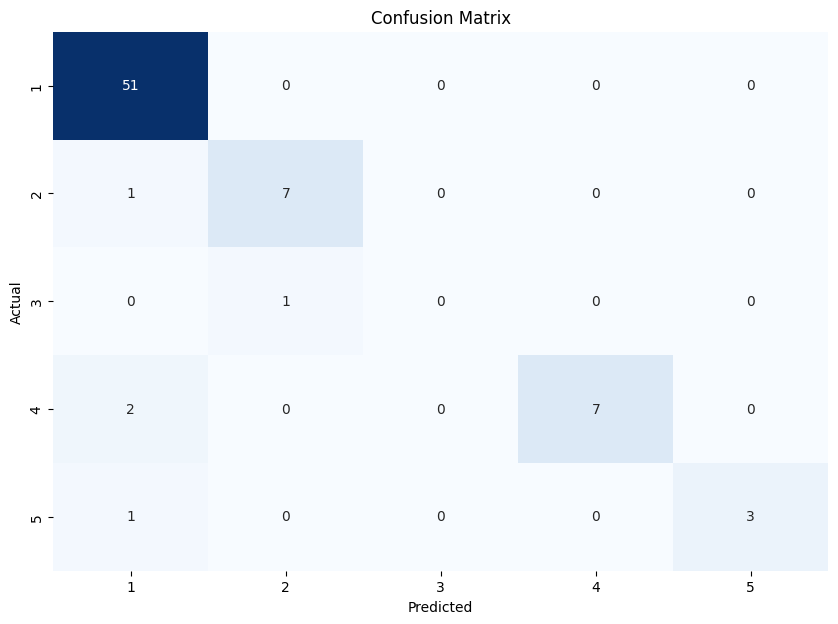

In [33]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


     Feature  Importance
4   Feature9    0.274883
7  Feature12    0.203654
5  Feature10    0.160932
6  Feature11    0.159376
3   Feature8    0.083527
1   Feature6    0.040863
8  Feature14    0.036638
2   Feature7    0.028815
0   Feature5    0.011311


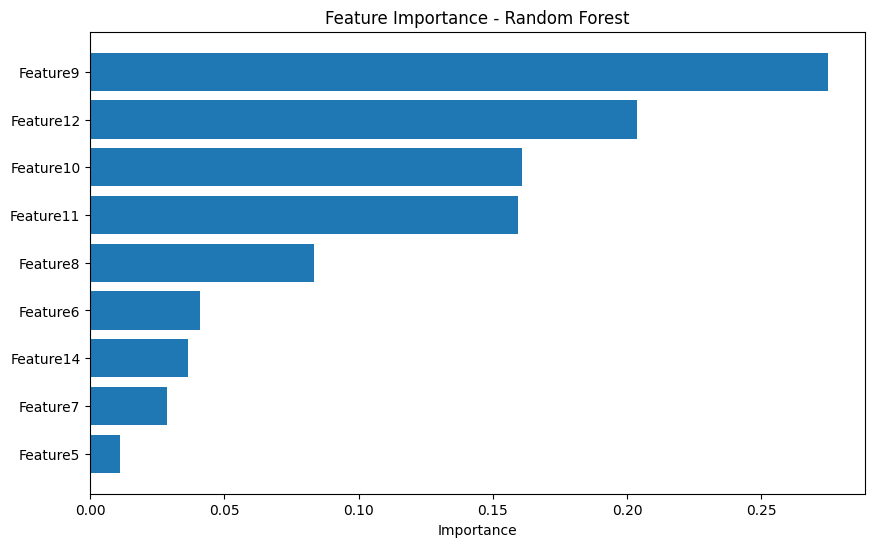

In [34]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [35]:
def objective_rf(trial, X_train, y_train):
    """Objective function for Optuna to optimize RandomForest hyperparameters."""
    
    # Define search space
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 20, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4, step=1)

    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=20,
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1  # Optuna tries to maximize this

In [36]:
def random_forest_classifier_with_optuna(X, y, n_trials=30):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_rf(trial, X_train, y_train), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = RandomForestClassifier(**best_params, random_state=20, n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-05-07 17:06:30,010] A new study created in memory with name: no-name-333aeba9-b710-4782-ab87-81702fdd3d6e
[I 2025-05-07 17:06:30,295] Trial 0 finished with value: 0.9287249704148468 and parameters: {'n_estimators': 70, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9287249704148468.
[I 2025-05-07 17:06:30,558] Trial 1 finished with value: 0.9292257749366646 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.9292257749366646.
[I 2025-05-07 17:06:30,696] Trial 2 finished with value: 0.9422423341494774 and parameters: {'n_estimators': 60, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.9422423341494774.
[I 2025-05-07 17:06:31,032] Trial 3 finished with value: 0.913440728294795 and parameters: {'n_estimators': 200, 'criterion': 'gini', '

Best Parameters: {'n_estimators': 160, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1}
Accuracy: 0.9589
F1 Score: 0.9513


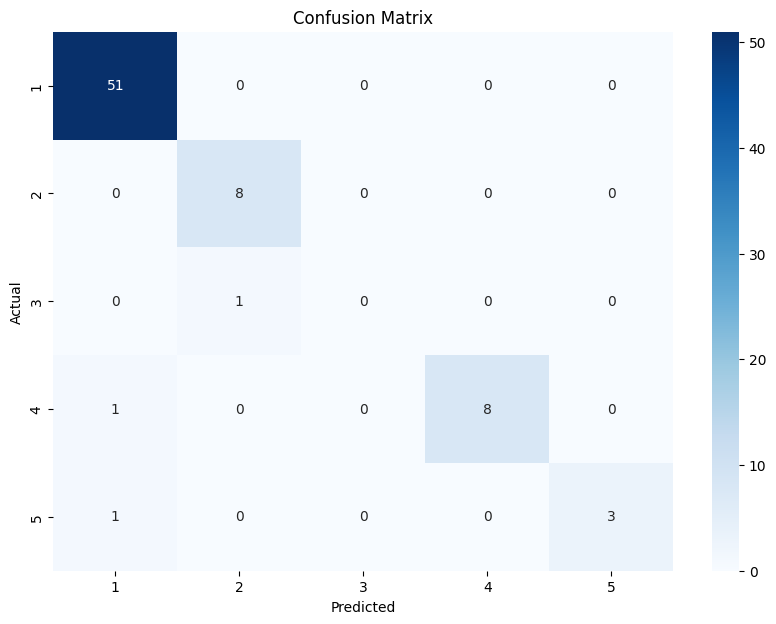

In [37]:
# Perform hyperparameter tuning and retrieve the best parameters
best_rf_model, best_rf_params, accuracy, f1, cm = random_forest_classifier_with_optuna(x_standardized, y)

#### KNN 

In [39]:
def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [40]:
def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.9041
F1 Score: 0.8938


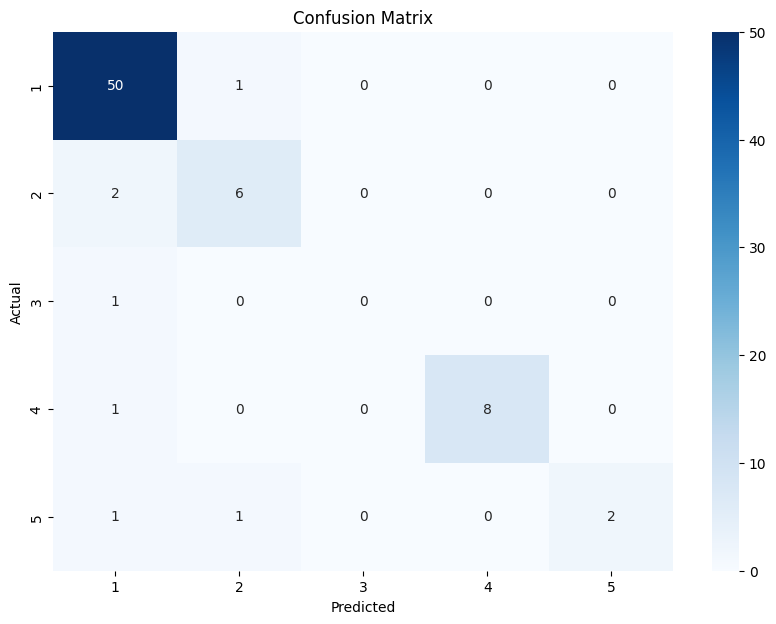

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1}
Best Score: 0.8900642898889538


In [41]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)
knn_best_params = knn_hyperparameter_tuning(x_standardized, y)

#### Progressive Validation

In [42]:
def progressive_validation(model, X, y, groups):
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []
    
    # Reset index to avoid mismatches
    X, y, groups = X.reset_index(drop=True), y.reset_index(drop=True), groups.reset_index(drop=True)
    sorted_indices = np.argsort(groups.to_numpy()) 
    X, y, groups = X.iloc[sorted_indices], y.iloc[sorted_indices], groups.iloc[sorted_indices]

    gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in gss.split(X, y, groups=groups):
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]  
        break 

    unique_classes = set(y.unique())
    for split in splits:
        subset_idx = train_idx[:int(len(train_idx) * split)]
        X_train, y_train = X.iloc[subset_idx], y.iloc[subset_idx]
        missing_classes = unique_classes - set(y_train.unique())
        if missing_classes:
            print(f"Adding missing classes: {missing_classes}")
            for cls in missing_classes:
                cls_indices = y_test[y_test == cls].index
                if len(cls_indices) > 0:
                    add_idx = cls_indices[0] 
                    X_train = pd.concat([X_train, X.loc[[add_idx]]])
                    y_train = pd.concat([y_train, y.loc[[add_idx]]])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results

Adding missing classes: {np.int64(2), np.int64(4)}


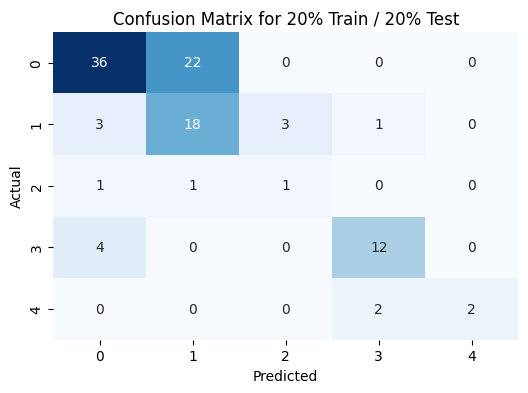

Results for 20% train / 20% test:
Accuracy: 0.6509
F1 Score: 0.6650
----------------------------------------
Adding missing classes: {np.int64(2), np.int64(4)}


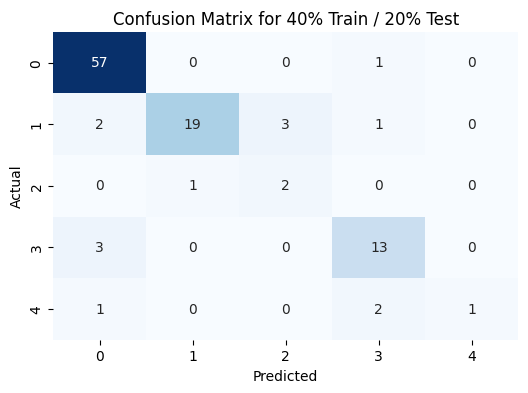

Results for 40% train / 20% test:
Accuracy: 0.8679
F1 Score: 0.8628
----------------------------------------
Adding missing classes: {np.int64(2)}


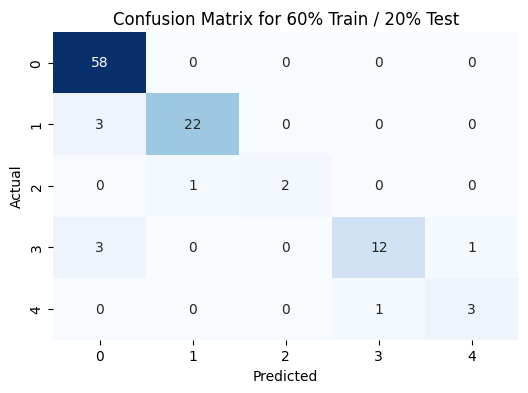

Results for 60% train / 20% test:
Accuracy: 0.9151
F1 Score: 0.9123
----------------------------------------


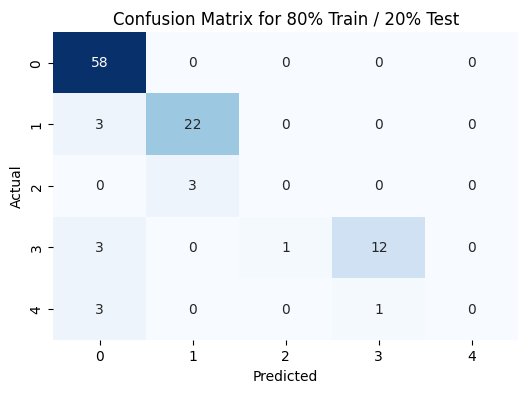

Results for 80% train / 20% test:
Accuracy: 0.8679
F1 Score: 0.8402
----------------------------------------
XGBoost Results:
{'split': '20% train / 20% test', 'accuracy': 0.6509433962264151, 'f1_score': np.float64(0.6649853434429711), 'confusion_matrix': array([[36, 22,  0,  0,  0],
       [ 3, 18,  3,  1,  0],
       [ 1,  1,  1,  0,  0],
       [ 4,  0,  0, 12,  0],
       [ 0,  0,  0,  2,  2]])}
{'split': '40% train / 20% test', 'accuracy': 0.8679245283018868, 'f1_score': np.float64(0.8628471680787289), 'confusion_matrix': array([[57,  0,  0,  1,  0],
       [ 2, 19,  3,  1,  0],
       [ 0,  1,  2,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 1,  0,  0,  2,  1]])}
{'split': '60% train / 20% test', 'accuracy': 0.9150943396226415, 'f1_score': np.float64(0.9123168581190382), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 3, 22,  0,  0,  0],
       [ 0,  1,  2,  0,  0],
       [ 3,  0,  0, 12,  1],
       [ 0,  0,  0,  1,  3]])}
{'split': '80% train / 20% test', 'accuracy

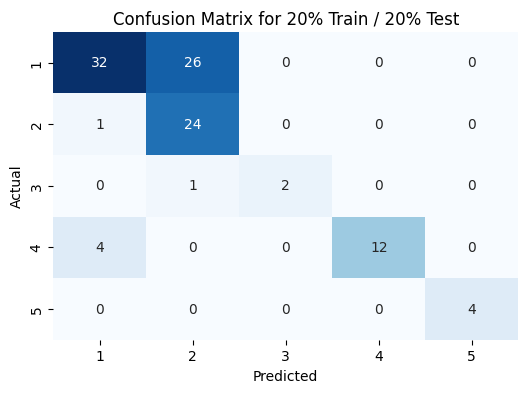

Results for 20% train / 20% test:
Accuracy: 0.6981
F1 Score: 0.7073
----------------------------------------
Adding missing classes: {np.int64(3), np.int64(5)}


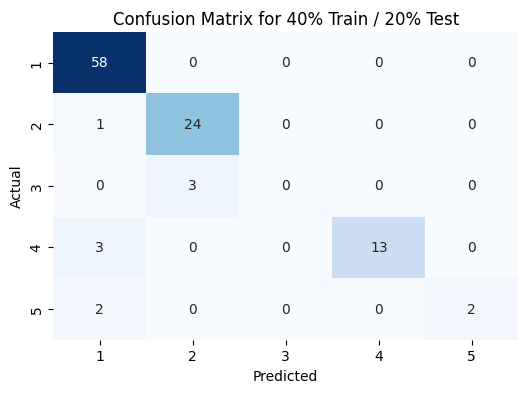

Results for 40% train / 20% test:
Accuracy: 0.9151
F1 Score: 0.8985
----------------------------------------
Adding missing classes: {np.int64(3)}


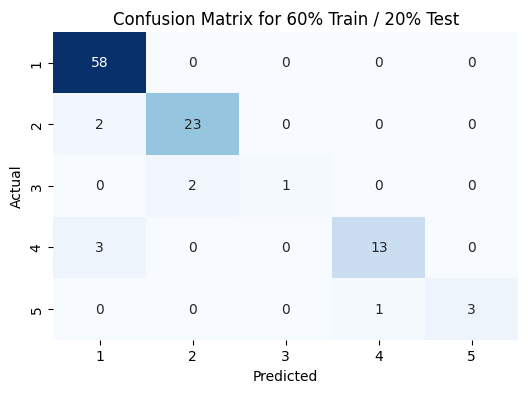

Results for 60% train / 20% test:
Accuracy: 0.9245
F1 Score: 0.9189
----------------------------------------


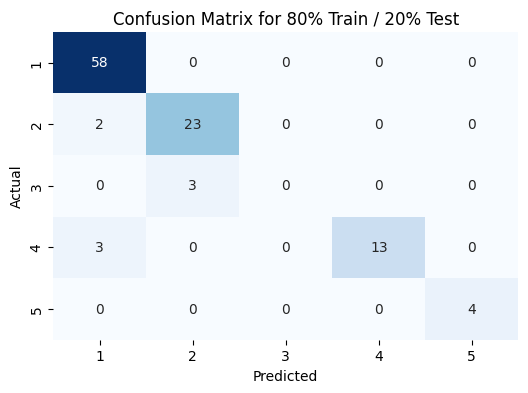

Results for 80% train / 20% test:
Accuracy: 0.9245
F1 Score: 0.9104
----------------------------------------
Random Forest Results:
{'split': '20% train / 20% test', 'accuracy': 0.6981132075471698, 'f1_score': np.float64(0.7073343736700242), 'confusion_matrix': array([[32, 26,  0,  0,  0],
       [ 1, 24,  0,  0,  0],
       [ 0,  1,  2,  0,  0],
       [ 4,  0,  0, 12,  0],
       [ 0,  0,  0,  0,  4]])}
{'split': '40% train / 20% test', 'accuracy': 0.9150943396226415, 'f1_score': np.float64(0.8984524369188981), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 1, 24,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 2,  0,  0,  0,  2]])}
{'split': '60% train / 20% test', 'accuracy': 0.9245283018867925, 'f1_score': np.float64(0.9188541875505857), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 2, 23,  0,  0,  0],
       [ 0,  2,  1,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 0,  0,  0,  1,  3]])}
{'split': '80% train / 20% test', 'ac

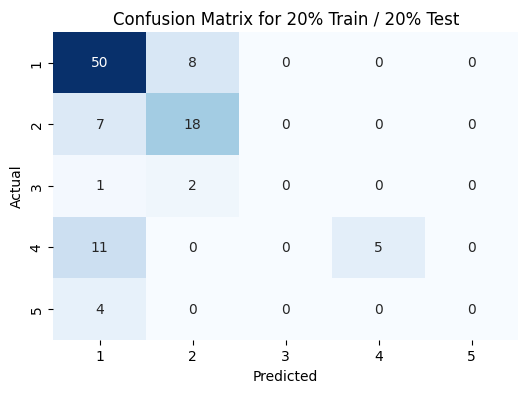

Results for 20% train / 20% test:
Accuracy: 0.6887
F1 Score: 0.6498
----------------------------------------
Adding missing classes: {np.int64(3), np.int64(5)}


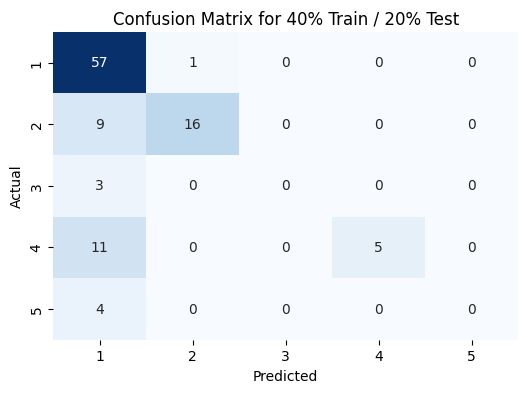

Results for 40% train / 20% test:
Accuracy: 0.7358
F1 Score: 0.6908
----------------------------------------
Adding missing classes: {np.int64(3)}


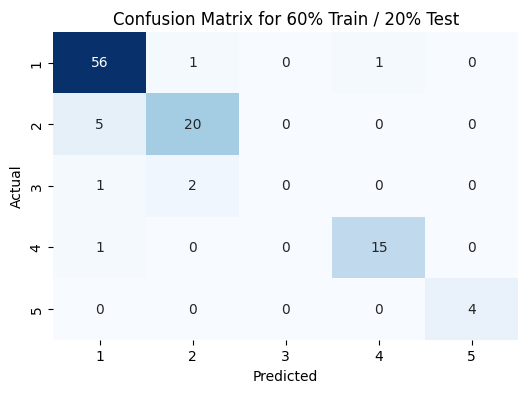

Results for 60% train / 20% test:
Accuracy: 0.8962
F1 Score: 0.8823
----------------------------------------


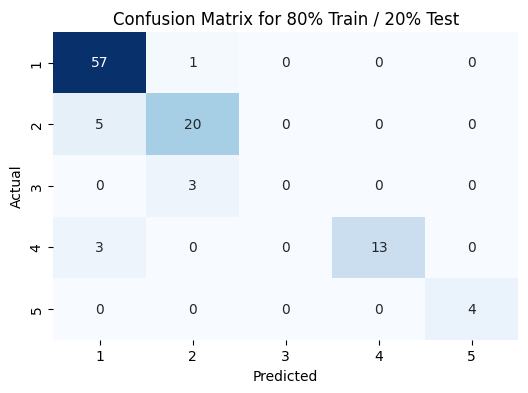

Results for 80% train / 20% test:
Accuracy: 0.8868
F1 Score: 0.8727
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.6886792452830188,
  'f1_score': np.float64(0.6497640458002327),
  'confusion_matrix': array([[50,  8,  0,  0,  0],
         [ 7, 18,  0,  0,  0],
         [ 1,  2,  0,  0,  0],
         [11,  0,  0,  5,  0],
         [ 4,  0,  0,  0,  0]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.7358490566037735,
  'f1_score': np.float64(0.6908494995128002),
  'confusion_matrix': array([[57,  1,  0,  0,  0],
         [ 9, 16,  0,  0,  0],
         [ 3,  0,  0,  0,  0],
         [11,  0,  0,  5,  0],
         [ 4,  0,  0,  0,  0]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.8962264150943396,
  'f1_score': np.float64(0.8822573938354386),
  'confusion_matrix': array([[56,  1,  0,  1,  0],
         [ 5, 20,  0,  0,  0],
         [ 1,  2,  0,  0,  0],
         [ 1,  0,  0, 15,  0],
         [ 0,  0,  0,  0,  4]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.8867924528301887,
  'f1_score': np.float64(0.8727272491744211),
  'con

In [43]:
# Run progressive validation
progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)
print("XGBoost Results:")
# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)
print("Random Forest Results:")
# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)